In [99]:
import yfinance as yf
import pandas as pd
import openpyxl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [100]:
#1) Escolha uma periodicidade (por exemplo, mensal ou semanal) e liste as cotações de
#fechamento para um determinado período de tempo (por exemplo, 6 meses, 1 ano, 5 anos).
#Certifique-se de que você tenha pelo menos 30 observações de cada ação.

# 1. Lista de tickers corrigida (com '^' no S&P 500)
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL", "META", "^GSPC"]

# 2. Download dos dados
# Use interval="1mo" para mensal ou interval="1wk" para semanal
precos = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-07-31",
    interval="1d",  # Periodicidade mensal
    auto_adjust=True
)["Close"]

[*********************100%***********************]  6 of 6 completed


In [101]:
# 1. Resetar o índice (se necessário)
precos = precos.reset_index()

# 2. Converter a data
precos["Date"] = pd.to_datetime(precos["Date"])

# 3. Criar a coluna do dia da semana (ANTES de definir 'Date' como índice)
precos["Weekday"] = precos["Date"].dt.day_name()

# 4. Definir 'Date' como índice
precos = precos.set_index("Date")

# 5. Identificar apenas as colunas numéricas (tickers)
colunas_tickers = [col for col in precos.columns if col != "Weekday"]

# 6.2. Calcular o retorno simples (percentual)
retorno_simples = precos[colunas_tickers].pct_change()

# 7. Adicionar o dia da semana nos DataFrames de retorno
retorno_simples["Weekday"] = precos["Weekday"]

# 8. Reordenar as colunas
cols_ordenadas = ["Weekday"] + colunas_tickers
precos = precos[cols_ordenadas]
retorno_simples = retorno_simples[cols_ordenadas]

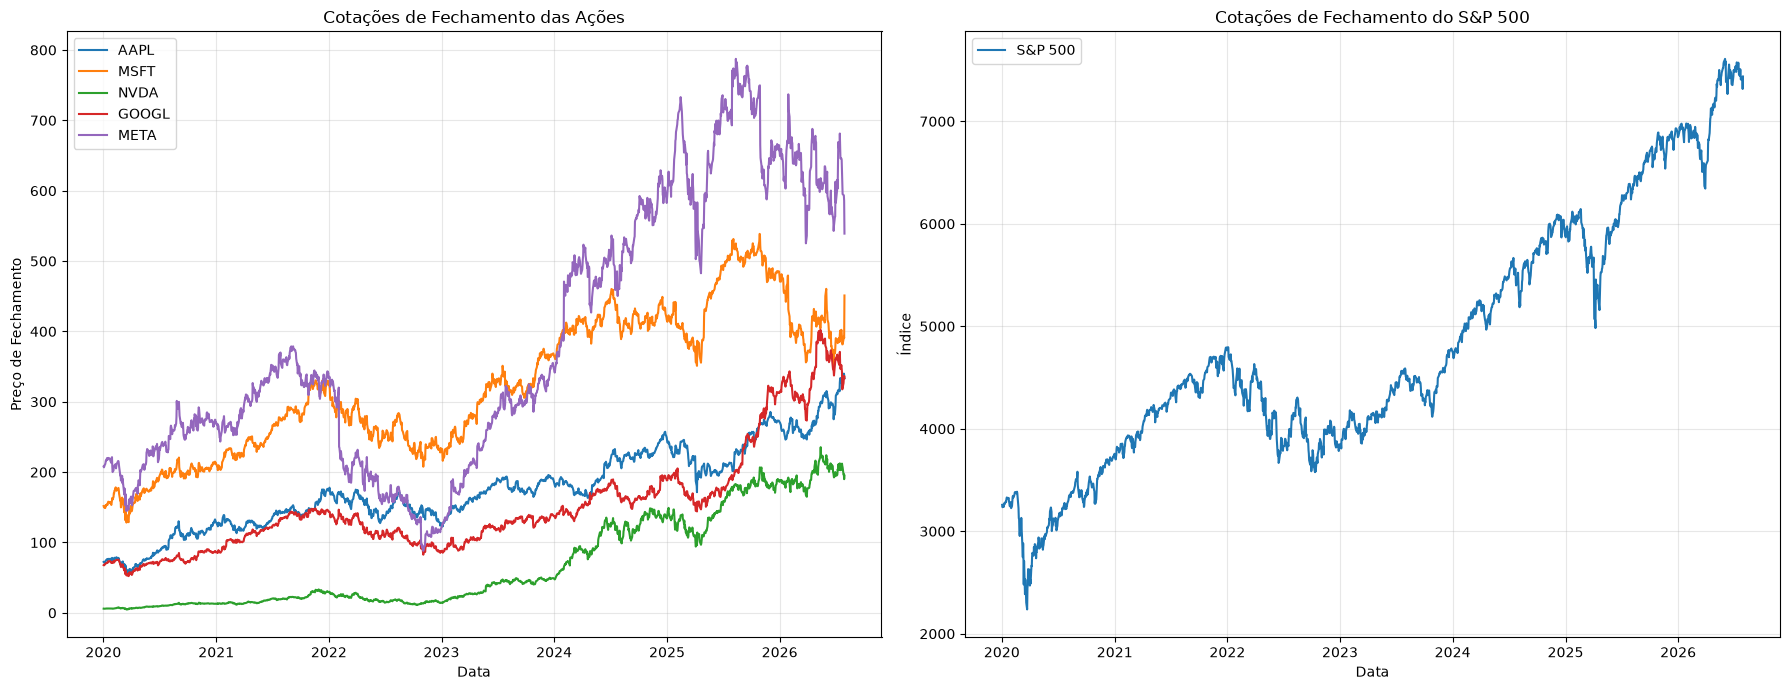

In [102]:
import matplotlib.pyplot as plt

# Separar ações e índice
acoes = ["AAPL", "MSFT", "NVDA", "GOOGL", "META"]
indice = "^GSPC"

# Remover linhas em que o S&P 500 não possui valor
sp500 = precos[indice].dropna()

# Criar dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ============================================================
# GRÁFICO 1 - PREÇOS DAS AÇÕES
# ============================================================

for ticker in acoes:
    axes[0].plot(
        precos.index,
        precos[ticker],
        label=ticker
    )

axes[0].set_title("Cotações de Fechamento das Ações")
axes[0].set_xlabel("Data")
axes[0].set_ylabel("Preço de Fechamento")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# ============================================================
# GRÁFICO 2 - S&P 500
# ============================================================

axes[1].plot(
    sp500.index,
    sp500.values,
    label="S&P 500"
)

axes[1].set_title("Cotações de Fechamento do S&P 500")
axes[1].set_xlabel("Data")
axes[1].set_ylabel("Índice")
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# Ajustar espaçamento
plt.tight_layout()

plt.show()

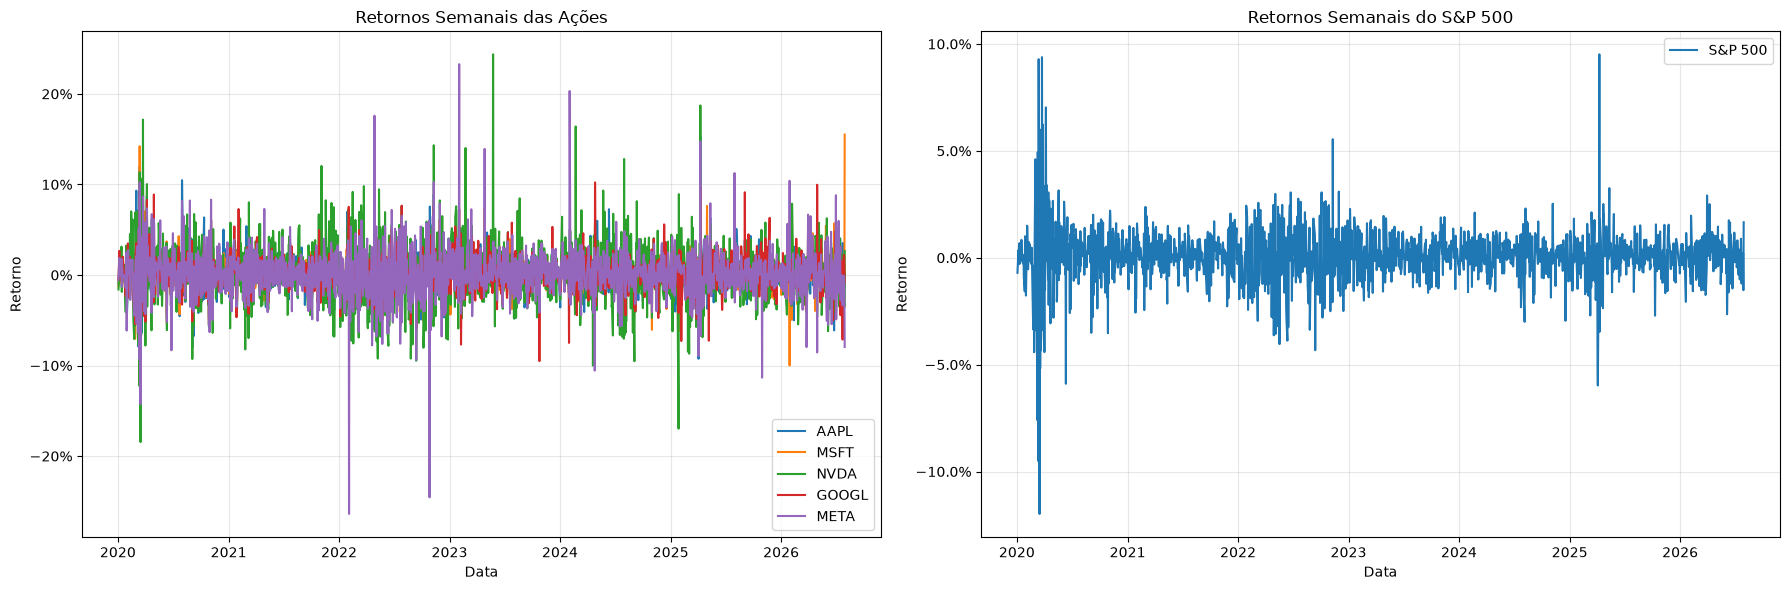

In [103]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Separar ações e índice
acoes = ["AAPL", "MSFT", "NVDA", "GOOGL", "META"]
indice = "^GSPC"

# Criar os dois gráficos lado a lado
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(18, 6)
)

# ============================================================
# GRÁFICO 1 - RETORNOS DAS AÇÕES
# ============================================================

for ticker in acoes:
    axes[0].plot(
        retorno_simples.index,
        retorno_simples[ticker],
        label=ticker
    )

axes[0].set_title("Retornos Semanais das Ações")
axes[0].set_xlabel("Data")
axes[0].set_ylabel("Retorno")
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# ============================================================
# GRÁFICO 2 - RETORNO DO S&P 500
# ============================================================

axes[1].plot(
    retorno_simples.index,
    retorno_simples[indice],
    label="S&P 500"
)

axes[1].set_title("Retornos Semanais do S&P 500")
axes[1].set_xlabel("Data")
axes[1].set_ylabel("Retorno")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# Ajustar espaçamento entre os gráficos
plt.tight_layout()

plt.show()

In [104]:
df = precos

# Garantir formato datetime no índice
df.index = pd.to_datetime(df.index)

# Remover a coluna 'Weekday' se ela existir
if "Weekday" in df.columns:
  df = df.drop(columns=["Weekday"])

# 1. Agrupar por semana finalizando na sexta-feira
precos_semanais = df.resample("W-FRI").last().dropna()

# 2. FILTRO: Manter apenas as datas que realmente existem na sexta-feira em 'df'
# Se a sexta-feira (ex: 2026-07-31) não existir em df.index, a semana é descartada.
precos_semanais = precos_semanais[precos_semanais.index.isin(df.index)]

# 3. Retorno Simples Semanal
retorno_simples_semanal = precos_semanais.pct_change().dropna()

In [105]:
#3) Calcule o desvio padrão dos retornos para cada ação do item 2.

std_simples_semanal = retorno_simples_semanal.std()
std_simples_anual = std_simples_semanal * np.sqrt(52)

# 5. Criar DataFrame Exclusivo de Desvio Padrão
resumo_desvio_padrao = pd.DataFrame(
    {
        "Desvio Padrão Simples (Semanal)": std_simples_semanal,
        "Volatilidade Anualizada (Simples)": std_simples_anual
    }
)

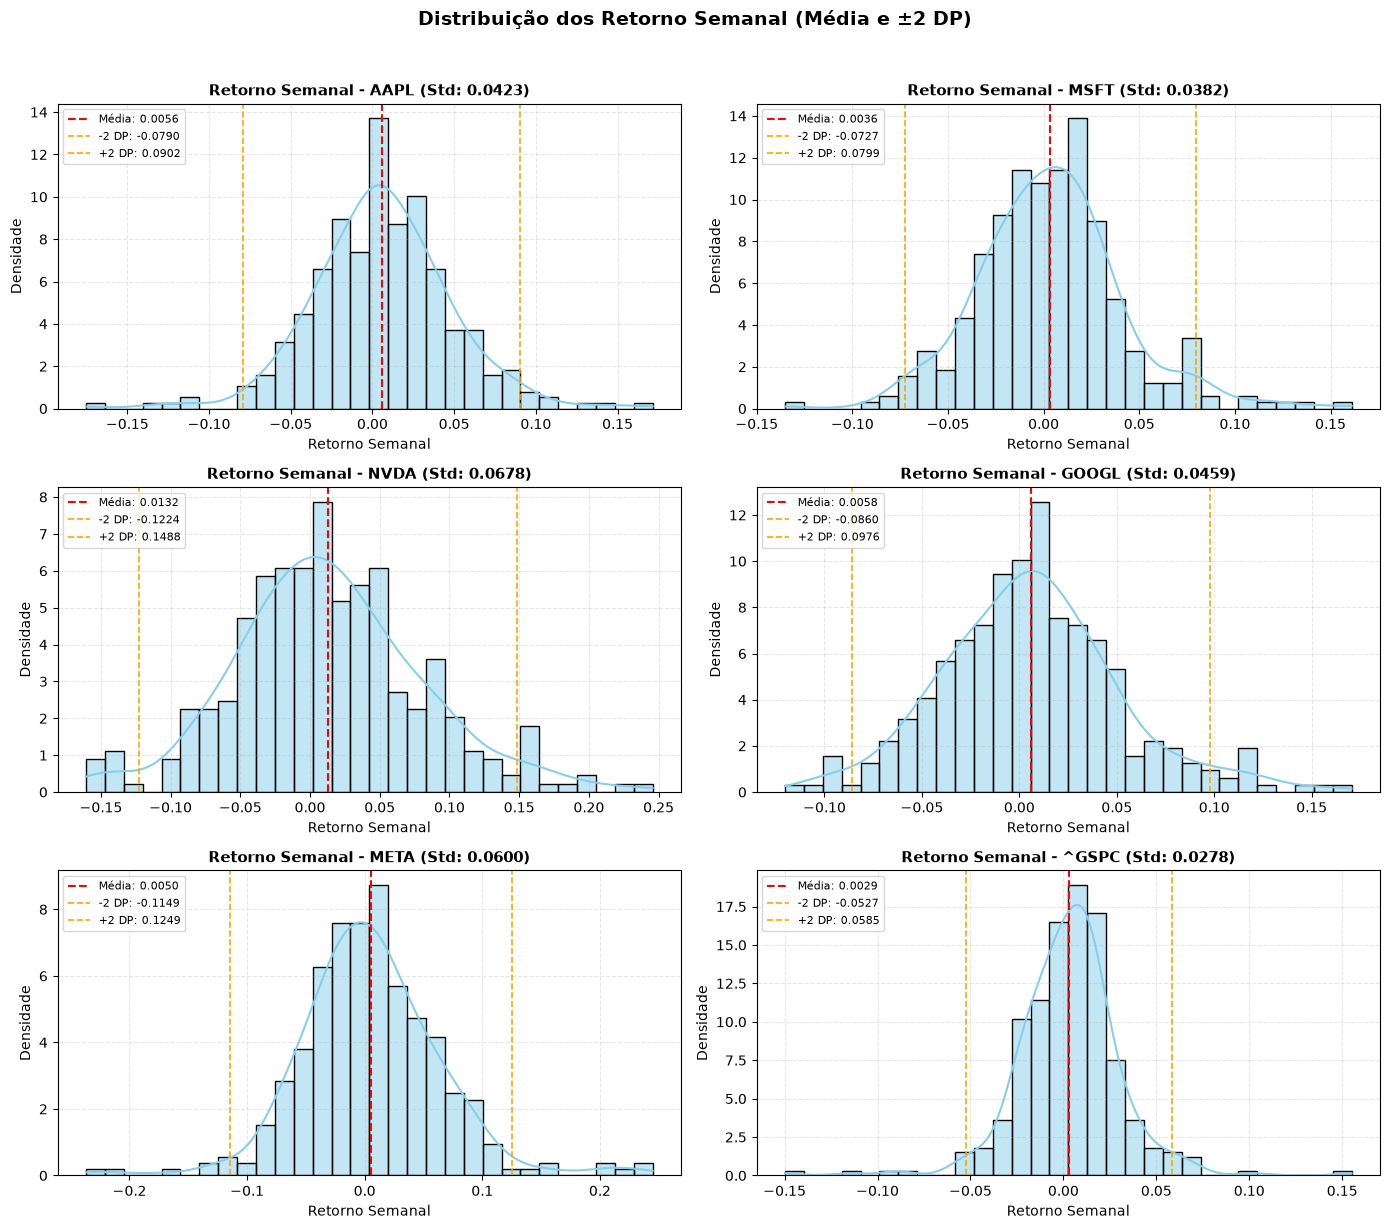

In [106]:
# Configurar a grade para exibir 2 gráficos por linha (2 colunas)
n_tickers = len(tickers)
ncols = 2
nrows = (n_tickers + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))

# Garantir tratamento para matriz de eixos 1D / 2D
if n_tickers == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()

for i, ticker in enumerate(tickers):
    ax = axes[i]
    dados_retorno = retorno_simples_semanal[ticker].dropna()
    media_log = dados_retorno.mean()
    desvio_log = dados_retorno.std()

    # Histograma com Curva de Densidade (KDE)
    sns.histplot(
        dados_retorno,
        kde=True,
        ax=ax,
        color="skyblue",
        bins=30,
        stat="density",
    )

    # Linha da Média
    ax.axvline(
        media_log,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Média: {media_log:.4f}",
    )

    # Linhas de -2 DP e +2 DP
    ax.axvline(
        media_log - 2 * desvio_log,
        color="orange",
        linestyle="--",
        linewidth=1.2,
        label=f"-2 DP: {media_log - 2*desvio_log:.4f}",
    )
    ax.axvline(
        media_log + 2 * desvio_log,
        color="orange",
        linestyle="--",
        linewidth=1.2,
        label=f"+2 DP: {media_log + 2*desvio_log:.4f}",
    )

    # Configuração dos rótulos
    ax.set_title(
        f"Retorno Semanal - {ticker} (Std: {desvio_log:.4f})",
        fontsize=11,
        fontweight="bold",
    )
    ax.set_xlabel("Retorno Semanal")
    ax.set_ylabel("Densidade")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, linestyle="--", alpha=0.3)

# Deletar subplots vazios caso a quantidade de tickers seja ímpar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Distribuição dos Retorno Semanal (Média e ±2 DP)",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout()
plt.show()

In [107]:
df_retornos_semanal = retorno_simples_semanal
ticker_indice = "^GSPC"

# 1. Lista de ações (excluindo o índice e a coluna 'Weekday')
acoes = [
    c for c in df_retornos_semanal.columns if c not in [ticker_indice, "Weekday"]
]

# 2. Beta Geral (Incondicional)
var_mercado = df_retornos_semanal[ticker_indice].var()

betas_geral = {
    acao: df_retornos_semanal[acao].cov(df_retornos_semanal[ticker_indice])
    / var_mercado
    for acao in acoes
}

df_betas_geral = pd.DataFrame.from_dict(
    betas_geral, orient="index", columns=["Beta CAPM Geral"]
)

# 3. Beta Móvel Semanal (Janela de 52 Semanas = 1 Ano)
janela_semanal = 52  # 52 semanas equivalem aos 252 dias úteis de 1 ano

var_movel_semanal = (
    df_retornos_semanal[ticker_indice]
    .rolling(window=janela_semanal, min_periods=janela_semanal)
    .var()
)

betas_moveis = {}

for acao in acoes:
    cov_movel = (
        df_retornos_semanal[acao]
        .rolling(window=janela_semanal, min_periods=janela_semanal)
        .cov(df_retornos_semanal[ticker_indice])
    )
    betas_moveis[acao] = cov_movel / var_movel_semanal

# Monta o DataFrame com a série temporal móvel semanal
df_betas_semanal_movel = pd.DataFrame(
    betas_moveis, index=df_retornos_semanal.index
).dropna(how="all")

print(df_betas_semanal_movel)

                      AAPL           GOOGL            META            MSFT  \
Date                                                                         
2021-01-29 1.0467232765309 0.8914854328766 0.9791288583846 0.8718761256796   
2021-02-05 1.0382854182852 0.9263139761277 0.9739243244257 0.8710341371646   
2021-02-12 1.0362829143522 0.9236696297191 0.9738688071824 0.8689112188712   
2021-02-19 1.0406725649537 0.9232450817864 0.9753356970960 0.8691390456599   
2021-02-26 1.0500186685253 0.9250510695339 0.9611774359355 0.8842305045107   
...                    ...             ...             ...             ...   
2026-06-12 1.0125779393613 1.7408982815406 1.9388114844923 1.2212420394659   
2026-06-26 1.0298085208758 1.7987151511637 1.9003239710285 1.2351356282962   
2026-07-10 1.1232875820140 1.7990766494277 2.1423588878599 1.2521223666146   
2026-07-17 1.0510591699514 1.7911157729038 2.1382953881721 1.2007801702514   
2026-07-24 1.1262034049754 1.8292134154843 2.1523379301073 1.199

In [108]:
rf = 0.0468      # 4,68%
mrp = 0.0530     # 5,30%

df_capm = df_betas_geral.copy()

df_capm["CAPM"] = rf + df_capm["Beta CAPM Geral"] * mrp
# Em porcentagem
df_capm["CAPM (%)"] = df_capm["CAPM"] * 100

In [109]:
# 1. Baixar a série do Yahoo Finance
tnx = yf.download("^TNX", start="2020-01-01", end="2026-07-30")["Close"]

# 2. AQUI o df_rf é criado a partir de 'tnx'
df_rf = pd.DataFrame(tnx)
df_rf.columns = ["Rf_anual_pct"]

# 3. Tratamento dos dados e conversão para taxa semanal
df_rf["Rf_anual"] = df_rf["Rf_anual_pct"].ffill() / 100
df_rf["Rf_semanal"] = (1 + df_rf["Rf_anual"]) ** (1 / 52) - 1

[*********************100%***********************]  1 of 1 completed


In [110]:
df_excesso = pd.DataFrame(index=retorno_simples_semanal.index)

# Define e arredonda a taxa livre de risco semanal (6 casas decimais)
if "Rf_semanal" in df_rf.columns:
    df_excesso["Rf_semanal"] = df_rf["Rf_semanal"].round(6)
else:
    rf_constante = (1 + 0.0468) ** (1 / 52) - 1
    df_excesso["Rf_semanal"] = round(rf_constante, 6)

# Calcula o excesso de retorno vetorizado para todas as colunas de ações
cols_acoes = [
    col for col in retorno_simples_semanal.columns if col != "Weekday"
]

for col in cols_acoes:
    df_excesso[col] = (
        retorno_simples_semanal[col] - df_excesso["Rf_semanal"]
    ).round(6)

df_excesso = df_excesso.dropna()

mercado_col = "^GSPC"
acoes = [col for col in df_excesso.columns if col not in [mercado_col, "Rf_semanal", "Weekday"]]

nome_arquivo = "Resultados_regressoes_resumido.xlsx"
nome_aba = "Resumo CAPM"

resultados = []

# Loop direto nas colunas do df_excesso
for acao in acoes:
    df_reg = df_excesso[[acao, mercado_col]].dropna()

    Y = df_reg[acao]
    X = sm.add_constant(df_reg[mercado_col])

    modelo = sm.OLS(Y, X).fit()
    
    conf_int = modelo.conf_int()

    # Compilação dos resultados chave
    resultados.append(
        {
            "Ativo": acao,
            "Beta (Modelo)": modelo.params[mercado_col],
            "Beta Stat t": modelo.tvalues[mercado_col],
            "Beta p-valor": modelo.pvalues[mercado_col],
            "Beta IC 95% Inf": conf_int.loc[mercado_col, 0],
            "Beta IC 95% Sup": conf_int.loc[mercado_col, 1],
            "Alfa (Interseção)": modelo.params["const"],
            "Alfa Stat t": modelo.tvalues["const"],
            "Alfa p-valor": modelo.pvalues["const"],
            "R2": modelo.rsquared,
            "R2 Ajustado": modelo.rsquared_adj,
            "Erro Padrão Modelo": np.sqrt(modelo.mse_resid),
            "Observações": int(modelo.nobs),
        }
    )

# Consolidação no DataFrame final
df_resumo_regressao = pd.DataFrame(resultados)


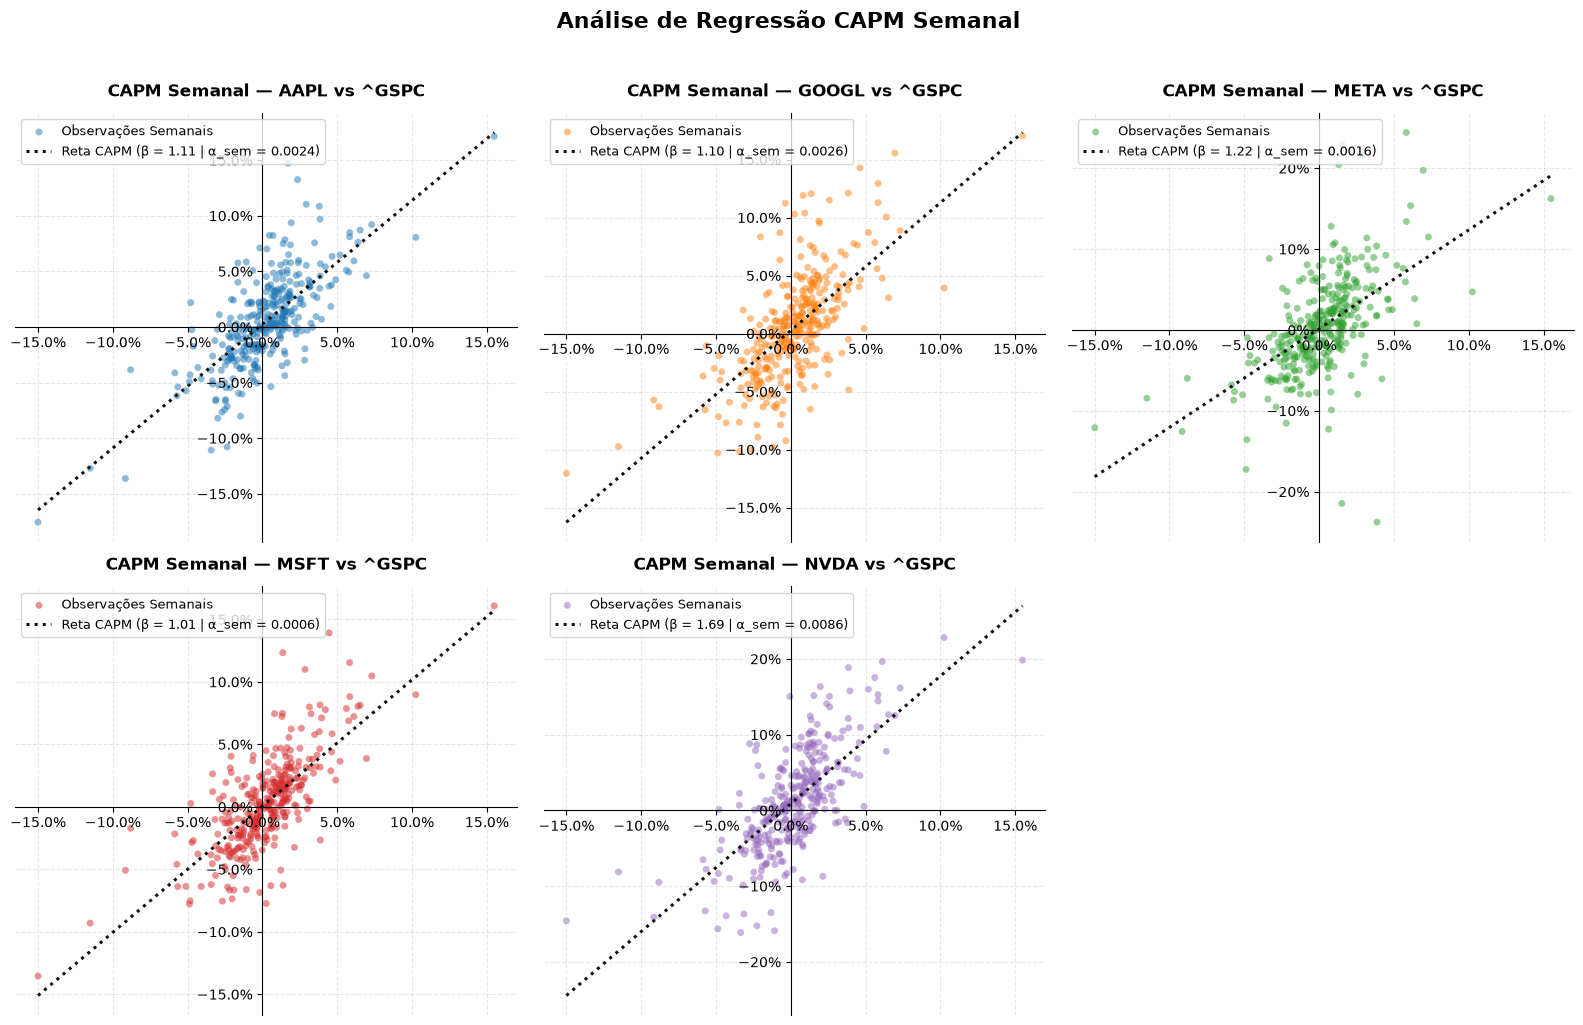

In [111]:
# ---------------------------------------------------------------------
# 1. Identificar o mercado e a lista de ações (Série Semanal)
# ---------------------------------------------------------------------
mercado_col = "^GSPC"
acoes = [col for col in df_retornos_semanal.columns if col != mercado_col]

# Tratamento da Taxa Livre de Risco Semanal
if "df_rf" in locals() and "Rf_semanal" in df_rf.columns:
    rf_semanal = df_rf["Rf_semanal"]
elif "df_rf" in locals() and "Rf_diario" in df_rf.columns:
    rf_semanal = (1 + df_rf["Rf_diario"]) ** 5 - 1
else:
    # Caso df_rf não exista, assume Rf anual de 4.68%
    rf_anual = 0.0468
    rf_semanal = (1 + rf_anual) ** (1 / 52) - 1

# ---------------------------------------------------------------------
# 2. Configurar a grade de subplots dinamicamente (3 colunas)
# ---------------------------------------------------------------------
n_acoes = len(acoes)
ncols = 3
nrows = (n_acoes + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 5 * nrows))
axes = axes.flatten() if n_acoes > 1 else [axes]

# Paleta de cores para os ativos
cores = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
]

# ---------------------------------------------------------------------
# 3. Iterar e plotar cada ação em frequência semanal
# ---------------------------------------------------------------------
for i, acao in enumerate(acoes):
    ax = axes[i]
    cor = cores[i % len(cores)]

    # A) Preparar base limpa em frequência semanal
    df_plot = (
        pd.DataFrame(
            {
                "X_excesso": df_retornos_semanal[mercado_col] - rf_semanal,
                "Y_excesso": df_retornos_semanal[acao] - rf_semanal,
            }
        )
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    X_excesso = df_plot["X_excesso"]
    Y_excesso = df_plot["Y_excesso"]

    # B) Regressão OLS (Statsmodels) + polyfit
    X_sm = sm.add_constant(X_excesso)
    modelo = sm.OLS(Y_excesso, X_sm).fit()
    alpha_sm = modelo.params["const"]
    beta_sm = modelo.params["X_excesso"]

    # C) Pontos da Reta CAPM
    x_linha = np.linspace(X_excesso.min(), X_excesso.max(), 100)
    y_linha = alpha_sm + beta_sm * x_linha

    # D) Plotar Dispersão e Reta
    ax.scatter(
        X_excesso,
        Y_excesso,
        color=cor,
        alpha=0.5,
        edgecolors="none",
        s=25,
        label="Observações Semanais",
    )
    ax.plot(
        x_linha,
        y_linha,
        linestyle=":",
        color="#111111",
        linewidth=2.2,
        label=f"Reta CAPM (β = {beta_sm:.2f} | α_sem = {alpha_sm:.4f})",
    )

    # E) Ajuste dos Eixos no (0,0)
    ax.spines["left"].set_position("zero")
    ax.spines["bottom"].set_position("zero")
    ax.spines["right"].set_color("none")
    ax.spines["top"].set_color("none")

    # F) Formatação em Porcentagem (%)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    ax.set_title(
        f"CAPM Semanal — {acao} vs {mercado_col}",
        fontsize=12,
        fontweight="bold",
        pad=12,
    )
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)

# Ocultar subplots vazios na grade
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    "Análise de Regressão CAPM Semanal",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

In [112]:
caminho_saida   = r"C:\Users\SURREAL\Documents\EVALUATION\analise_completa_semanal_python.xlsx"

with pd.ExcelWriter(caminho_saida, engine="openpyxl") as writer:
    precos.to_excel(writer, sheet_name="Preços")
    retorno_simples_semanal.to_excel(writer, sheet_name="Retorno Simples Semanal")
    resumo_desvio_padrao.to_excel(writer, sheet_name="Desvio Padrão")
    df_betas_geral.to_excel( writer, sheet_name="Beta CAPM Geral" )
    df_betas_semanal_movel.to_excel(writer, sheet_name="Beta Diário")
    df_capm.to_excel(writer, sheet_name="CAPM")
    df_rf.to_excel(writer, sheet_name="TNX Histórico")
    df_excesso.to_excel(writer, sheet_name="Excesso de Retornos")
    df_resumo_regressao.to_excel(writer, sheet_name="Resumo Regressao")

    